# Spline SPF Injection-Recovery

This notebook demonstrates **injection-recovery** for a flexible spline scattering phase function (SPF) in GRaTeR-JAX.

In scattered-light imaging of debris disks, the **scattering phase function** (SPF) encodes how dust grains scatter starlight as a function of the angle between the incident and scattered rays. Recovering the SPF from disk images constrains dust grain properties — size, composition, and porosity — that are otherwise inaccessible.

GRaTeR-JAX supports a flexible **spline SPF** that can represent arbitrary shapes, unlike the single-parameter Henyey-Greenstein (HG) model. The spline is parameterised by a small number of free knot values, making it tractable for both maximum-likelihood optimisation and Bayesian MCMC posterior inference.

**Injection-recovery** is a standard validation strategy: we synthesise a disk image using a *known* SPF (here, a HG with $g = 0.3$), then attempt to recover the SPF using the flexible spline model. Agreement between the recovered and injected SPF validates the modelling pipeline and quantifies the recovery fidelity.

This notebook will:
1. Generate truth images at four disk inclinations (30°, 50°, 70°, 80°).
2. Fit the spline SPF to each truth image with **scipy L-BFGS-B** optimisation.
3. Run **MCMC posterior inference** with `emcee` to quantify uncertainty on the recovered SPF.
4. Summarise the recovery fidelity across inclinations.

## Background

### Henyey-Greenstein SPF

The Henyey-Greenstein (HG) phase function is the standard single-parameter model for dust scattering:

$$f(\theta) = \frac{1}{4\pi}\frac{1-g^2}{[1+g^2 - 2g\cos\theta]^{3/2}}$$

where $\theta$ is the scattering angle and $g \in (-1, 1)$ is the **asymmetry parameter** ($g > 0$ forward-scattering, $g < 0$ backward-scattering, $g = 0$ isotropic). While analytically convenient, the HG model has only one free parameter and cannot reproduce the rich scattering behaviour of real grain populations.

### Spline SPF

The spline SPF replaces the analytic HG formula with a **cubic spline** interpolated over $N_k$ free knot values across the probed range of $\cos\phi$ (where $\phi$ is the scattering angle). This gives much greater flexibility:

- **Knot locations** are evenly distributed across the range of $\cos\phi$ probed by the disk geometry, plus a small buffer (`KNOT_BOUND_BUFFER = 0.1` in $\cos\phi$ units) beyond the probed range.
- **A fixed knot is always placed at $\cos\phi = 0$ (90°)** with value 1. This normalisation means the spline value at 90° is always 1, so the absolute flux scaling (`flux_scaling`) and the SPF amplitude are not degenerate. All SPF comparisons in this notebook are therefore on a *normalised* scale.
- **Free knot values** (the $N_k$ parameters to be optimised) are the spline values at all positions *except* the fixed centre knot.

### Angular coverage and the inclination limit

A disk at inclination $i$ probes scattering angles from approximately $90° - i$ to $90° + i$ (forward to backward). Equivalently, the probed range in $\cos\phi$ is $(-\sin i, +\sin i)$. At low inclinations this window is narrow, and the spline has little angular leverage. The `recommended_num_knots` utility scales $N_k$ with the probed window, with a **minimum of 4** (fewer knots leads to underdetermined systems and local-minimum failures). This sets a practical lower inclination limit of roughly 28°.

### Injection-recovery as validation

We synthesise a truth image $I_{\rm true}$ from a known HG SPF, then attempt to recover it with the spline model. Any discrepancy between the recovered spline and the true HG reveals either (a) degeneracies in the model, (b) fitting failures, or (c) intrinsic limits set by the angular coverage. Across the probed angular range, we expect sub-percent recovery when the model is correct.

## Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax
import jax.numpy as jnp
import emcee

# Enable 64-bit precision for numerical stability in optimization and MCMC
jax.config.update("jax_enable_x64", True)
# Limit JAX memory fraction to leave room for other processes
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.5"

from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
from grater_jax.disk_model.SLD_utils import (
    DustEllipticalDistribution2PowerLaws,
    HenyeyGreenstein_SPF,
    InterpolatedUnivariateSpline_SPF,
    recommended_num_knots,
)
from grater_jax.disk_model.objective_functions import Parameter_Index
from grater_jax.optimization.optimize_framework import Optimizer

2026-03-30 12:06:59.116981: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


All constants are collected in one place below. Keeping magic numbers here (rather than scattered through code) makes it easy to re-run the notebook with different configurations.

In [2]:
# ── True SPF parameters ───────────────────────────────────────────────────────
G_TRUE    = 0.3          # true HG asymmetry parameter
INIT_G    = 0.5          # assumed g for initialising spline knots (not a constraint)

# ── Disk / image setup ────────────────────────────────────────────────────────
NX, NY    = 140, 140
FLUX      = 1e6
NUM_KNOTS = 6            # requested knot count for full angular range
FIT_ITERS = 2000

# ── Knot placement ───────────────────────────────────────────────────────────
KNOT_BOUND_BUFFER = 0.1  # cos(φ) buffer beyond probed range for knot boundaries

# ── Inclinations to test ──────────────────────────────────────────────────────
INCLINATIONS = [30.0, 50.0, 70.0, 80.0]

# ── MCMC settings ─────────────────────────────────────────────────────────────
NWALKERS  = 64
NITER     = 2000
BURNS     = 200
MCMC_DIR  = "mcmc_backends"

# ── Convenience: HG value at 90° (cos φ = 0); used for flux initialisation ───
# The spline SPF is normalised to 1 at 90°, so flux_scaling must absorb
# the HG value at that angle to produce the correct total flux.
hg_at_90  = float((1.0 / (4.0 * np.pi)) * (1 - G_TRUE**2) / (1 + G_TRUE**2)**1.5)

# ── Base parameter dictionaries ───────────────────────────────────────────────
BASE_MISC = Parameter_Index.misc_params.copy()
BASE_MISC.update({
    "nx": NX, "ny": NY,
    "distance": 50.0,
    "pxInArcsec": 0.01225,
    "halfNbSlices": 25,
    "flux_scaling": FLUX,
})

BASE_DISK = Parameter_Index.disk_params.copy()
BASE_DISK.update({
    "sma": 46.0, "alpha_in": 5.0, "alpha_out": -5.0,
    "ksi0": 1.0, "gamma": 2.0, "beta": 1.0,
    "e": 0.0, "dens_at_r0": 1.0,
    "position_angle": 0.0, "omega": 0.0,
    "x_center": NX / 2, "y_center": NY / 2,
    "halfNbSlices": 25,
})

HG_SPF_PARAMS = HenyeyGreenstein_SPF.params.copy()
HG_SPF_PARAMS["g"] = G_TRUE

In [3]:
def hg_normalized(cos_phi, g):
    """HG SPF normalised to 1 at cos_phi=0 (scattering angle = 90°)."""
    raw  = (1.0 / (4.0 * np.pi)) * (1 - g**2) / (1 + g**2 - 2*g*cos_phi)**1.5
    norm = (1.0 / (4.0 * np.pi)) * (1 - g**2) / (1 + g**2)**1.5
    return raw / norm


def probed_cosphi_range(incl_deg):
    """cos(φ) range probed by a disk at the given inclination: (−sin i, +sin i)."""
    s = np.sin(np.radians(incl_deg))
    return -s, s


# Dense grid for evaluating SPF curves
cos_grid = np.linspace(-1.0, 1.0, 500)
angles   = np.degrees(np.arccos(cos_grid))   # scattering angle in degrees

## The True SPF and Angular Coverage

Before fitting anything, it is instructive to visualise (a) the true HG SPF and (b) the range of scattering angles that each disk inclination actually probes. The shaded grey regions below fall *outside* the probed range — the spline has no direct data constraint there, and any apparent agreement is due to extrapolation only.

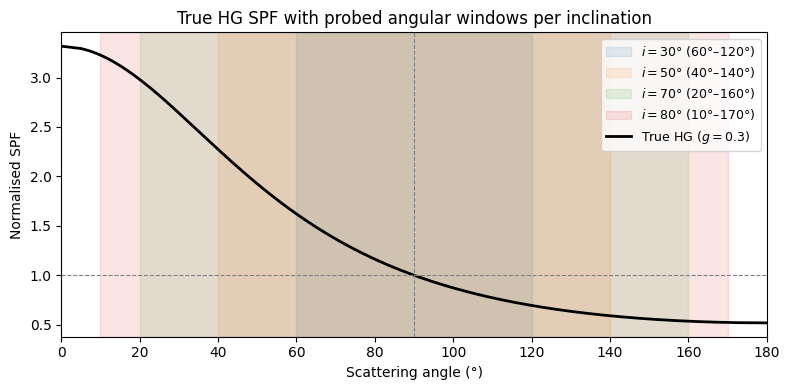

 Inclination    Probed cos-phi range    Probed angle range    Nk
-----------------------------------------------------------------
         30°  [-0.500, +0.500]           60.0° – 120.0°             4
         50°  [-0.766, +0.766]           40.0° – 140.0°             4
         70°  [-0.940, +0.940]           20.0° – 160.0°             6
         80°  [-0.985, +0.985]           10.0° – 170.0°             6


In [4]:
true_spf_curve = hg_normalized(cos_grid, G_TRUE)

fig, ax = plt.subplots(figsize=(8, 4))

colors = ["C0", "C1", "C2", "C3"]

for incl, col in zip(INCLINATIONS, colors):
    cp_back, cp_fwd = probed_cosphi_range(incl)
    ang_fwd  = float(np.degrees(np.arccos(cp_fwd)))
    ang_back = float(np.degrees(np.arccos(cp_back)))
    # Shade the probed region (not grayed out)
    ax.axvspan(ang_fwd, ang_back, alpha=0.12, color=col,
               label=f"$i={incl:.0f}$° ({ang_fwd:.0f}°–{ang_back:.0f}°)")

ax.plot(angles, true_spf_curve, "k-", lw=2, label=f"True HG ($g={G_TRUE}$)")
ax.axvline(90, color="grey", ls="--", lw=0.8)
ax.axhline(1.0, color="grey", ls="--", lw=0.8)

ax.set_xlabel("Scattering angle (°)")
ax.set_ylabel("Normalised SPF")
ax.set_title("True HG SPF with probed angular windows per inclination")
ax.set_xlim(0, 180)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# Print probed-range table
print(f"{'Inclination':>12}  {'Probed cos-phi range':>22}  {'Probed angle range':>20}  {'Nk':>4}")
print("-" * 65)
for incl in INCLINATIONS:
    cp_back, cp_fwd = probed_cosphi_range(incl)
    ang_fwd  = float(np.degrees(np.arccos(cp_fwd)))
    ang_back = float(np.degrees(np.arccos(cp_back)))
    nk = recommended_num_knots(incl, NUM_KNOTS, boundary_buffer=KNOT_BOUND_BUFFER)
    print(f"{incl:>11.0f}°  [{cp_back:+.3f}, {cp_fwd:+.3f}]         "
          f"{ang_fwd:>6.1f}° – {ang_back:>5.1f}°          {nk:>4}")

## Generating Synthetic Observations

We generate a noiseless truth image using the HG SPF and create a **photon-noise-like error map**:

$$\sigma(x,y) = \sqrt{|I(x,y)|} \times \sqrt{I_{\rm max}} \times 0.01$$

This mimics the shape of Poisson (photon-counting) noise — pixels with more signal have larger absolute uncertainty — without requiring actual shot-noise realisations. It gives the optimiser a realistic signal-to-noise weighting without introducing stochastic variation that would make the notebook non-reproducible.

incl=30°  truth max=3.7960e+01  err max=3.7960e-01
incl=50°  truth max=7.1337e+01  err max=7.1337e-01
incl=70°  truth max=1.7077e+02  err max=1.7077e+00
incl=80°  truth max=3.2734e+02  err max=3.2734e+00


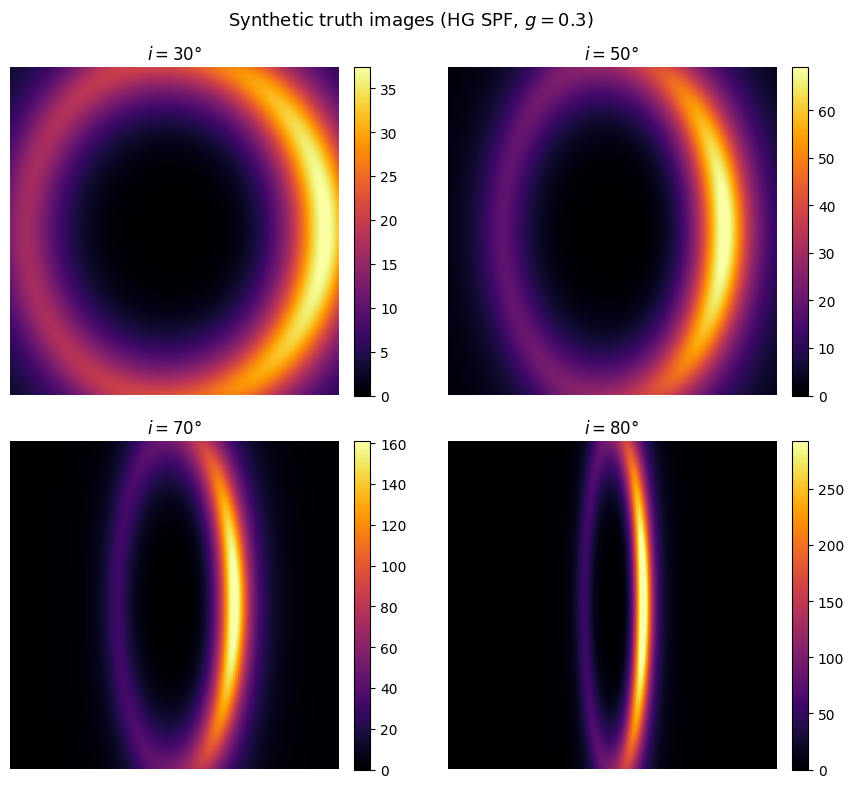

In [5]:
truth_images = {}
err_maps     = {}

for incl in INCLINATIONS:
    disk_params = BASE_DISK.copy()
    disk_params["inclination"] = incl

    truth_misc = BASE_MISC.copy()
    truth_misc["flux_scaling"] = FLUX

    truth_opt = Optimizer(
        ScatteredLightDisk, DustEllipticalDistribution2PowerLaws,
        HenyeyGreenstein_SPF, None,
        disk_params, HG_SPF_PARAMS, None, truth_misc,
    )
    truth_img = np.array(truth_opt.get_model())
    err_map   = np.sqrt(np.abs(truth_img)) * np.sqrt(truth_img.max()) * 0.01

    truth_images[incl] = truth_img
    err_maps[incl]     = err_map
    print(f"incl={incl:.0f}°  truth max={truth_img.max():.4e}  err max={err_map.max():.4e}")

# ── 2×2 panel of truth images ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, incl in zip(axes.flat, INCLINATIONS):
    img = truth_images[incl]
    vmax = np.percentile(img, 99.5)
    im = ax.imshow(img, origin="lower", cmap="inferno", vmin=0, vmax=vmax)
    ax.set_title(f"$i = {incl:.0f}$°")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Synthetic truth images (HG SPF, $g=0.3$)", fontsize=13)
plt.tight_layout()
plt.show()

## Spline Model Setup

Several design choices matter here:

**`recommended_num_knots`** scales the number of knots with the probed angular window, using
$$N_k = \max\left(4,\ \text{round}\left(N_{\rm full} \cdot \frac{\text{probed window}}{2}\right)\right)$$
The **minimum of 4** is enforced because fewer knots leads to an underdetermined or highly degenerate optimisation landscape with many local minima. This minimum is the reason there is a practical lower inclination limit of roughly 28°: below that, the probed window is too narrow to fit 4 knots reliably.

**Knot boundary buffer** of 0.1 in $\cos\phi$ places the outermost knots slightly beyond the probed range. This prevents the spline from being forced to extrapolate immediately at the boundary and generally improves numerical stability.

**HG initialisation** sets the starting knot values to the normalised HG curve (with $g = $ `INIT_G` = 0.5) evaluated at each free knot position. Starting from flat knot values (all ones) fails at low inclinations, where the narrow probed window provides only a weak gradient signal — the optimiser stalls near the flat-spline local minimum. Starting from a sensible physical shape (forward-peaked) gives a reliable warm start.

**Flux scaling initialisation**: Because the spline is normalised to 1 at 90°, the `flux_scaling` parameter must carry the physical flux value that the HG SPF had at 90°. We therefore initialise `flux_scaling = FLUX * hg_at_90`, where `hg_at_90` is the unnormalised HG value at $\theta = 90$°. This ensures the model flux is correct from the start.

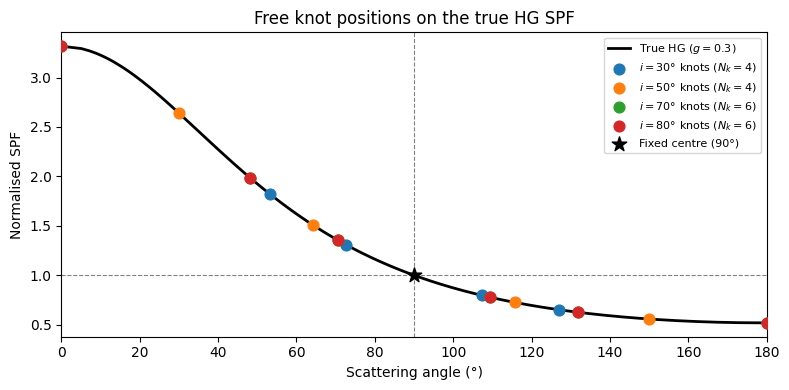

 Inclination    Nk  Notes
--------------------------------------------------
         30°     4  (minimum; window too narrow for more)
         50°     4  (minimum; window too narrow for more)
         70°     6  
         80°     6  


In [6]:
# Show recommended knot counts and visualise knot positions on the SPF curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(angles, true_spf_curve, "k-", lw=2, label=f"True HG ($g={G_TRUE}$)")

for incl, col in zip(INCLINATIONS, colors):
    cp_back, cp_fwd = probed_cosphi_range(incl)
    fwd_bound  = float(np.clip(cp_fwd  + KNOT_BOUND_BUFFER, -1.0, 1.0))
    back_bound = float(np.clip(cp_back - KNOT_BOUND_BUFFER, -1.0, 1.0))
    nk = recommended_num_knots(incl, NUM_KNOTS, boundary_buffer=KNOT_BOUND_BUFFER)

    # Build spf_params just to get knot positions
    spf_params_tmp = InterpolatedUnivariateSpline_SPF.params.copy()
    spf_params_tmp["num_knots"]          = nk
    spf_params_tmp["knot_values"]        = jnp.ones(nk)
    spf_params_tmp["forwardscatt_bound"] = fwd_bound
    spf_params_tmp["backscatt_bound"]    = back_bound

    knot_cos = np.array(InterpolatedUnivariateSpline_SPF.get_knots(spf_params_tmp))
    # Drop the fixed centre knot (cos_phi = 0) from the free-knot display
    n_left_init   = nk // 2
    free_knot_cos = np.concatenate([knot_cos[:n_left_init], knot_cos[n_left_init + 1:]])
    knot_angles   = np.degrees(np.arccos(free_knot_cos))
    knot_spf_vals = hg_normalized(free_knot_cos, G_TRUE)

    ax.scatter(knot_angles, knot_spf_vals, color=col, s=60, zorder=5,
               label=f"$i={incl:.0f}$° knots ($N_k={nk}$)")

ax.scatter([90], [1.0], marker="*", s=120, c="k", zorder=6, label="Fixed centre (90°)")
ax.axvline(90, color="grey", ls="--", lw=0.8)
ax.axhline(1.0, color="grey", ls="--", lw=0.8)
ax.set_xlabel("Scattering angle (°)")
ax.set_ylabel("Normalised SPF")
ax.set_title("Free knot positions on the true HG SPF")
ax.set_xlim(0, 180)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

print(f"{'Inclination':>12}  {'Nk':>4}  {'Notes'}")
print("-" * 50)
for incl in INCLINATIONS:
    nk = recommended_num_knots(incl, NUM_KNOTS, boundary_buffer=KNOT_BOUND_BUFFER)
    note = "(minimum; window too narrow for more)" if nk == 4 else ""
    print(f"{incl:>11.0f}°  {nk:>4}  {note}")

## Scipy Injection-Recovery

We use **L-BFGS-B** bounded optimisation (via `scipy.optimize.minimize`) to find the maximum-likelihood spline SPF. The optimisation is run with `use_grad=False`, meaning finite-difference gradients rather than JAX autodiff. Tests showed identical recovery accuracy at this parameter scale (~4–6 free parameters), and finite-difference mode is faster here because the JAX JIT compilation overhead dominates for small parameter counts — the computational advantage of autodiff only exceeds JIT overhead at ~20+ free parameters.

Bounds are set to prevent nonphysical knot values: $[10^{-6}, 10^3]$ for each knot (normalised SPF value) and $[10^2, 10^{12}]$ for `flux_scaling`. This cell takes approximately 10–30 seconds.

In [7]:
results = {}

for incl in INCLINATIONS:
    print(f"\n{'='*55}\nInclination = {incl:.0f}°")

    cp_back, cp_fwd = probed_cosphi_range(incl)
    nk          = recommended_num_knots(incl, NUM_KNOTS, boundary_buffer=KNOT_BOUND_BUFFER)
    fwd_bound   = float(np.clip(cp_fwd  + KNOT_BOUND_BUFFER, -1.0, 1.0))
    back_bound  = float(np.clip(cp_back - KNOT_BOUND_BUFFER, -1.0, 1.0))

    truth_img   = truth_images[incl]
    err_map     = err_maps[incl]

    # Build spline optimizer
    disk_params = BASE_DISK.copy()
    disk_params["inclination"] = incl

    spf_params = InterpolatedUnivariateSpline_SPF.params.copy()
    spf_params["num_knots"]          = nk
    spf_params["knot_values"]        = jnp.ones(nk)
    spf_params["forwardscatt_bound"] = fwd_bound
    spf_params["backscatt_bound"]    = back_bound

    fit_misc = BASE_MISC.copy()
    fit_misc["flux_scaling"] = FLUX * hg_at_90

    opt = Optimizer(
        ScatteredLightDisk, DustEllipticalDistribution2PowerLaws,
        InterpolatedUnivariateSpline_SPF, None,
        disk_params, spf_params, None, fit_misc,
    )

    # Warm-start knots from HG shape (avoids flat-spline local minimum at low inclinations)
    knot_cos      = np.array(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params))
    n_left_init   = nk // 2
    free_knot_cos = np.concatenate([knot_cos[:n_left_init], knot_cos[n_left_init + 1:]])
    opt.spf_params["knot_values"]   = jnp.array(hg_normalized(free_knot_cos, INIT_G))
    opt.misc_params["flux_scaling"] = FLUX * hg_at_90

    joint_bounds = ([np.full(nk, 1e-6), 1e2], [np.full(nk, 1e3), 1e12])

    # Up to 3 passes; stop early on convergence
    for pass_num in range(1, 4):
        soln = opt.scipy_bounded_optimize(
            fit_keys=["knot_values", "flux_scaling"],
            fit_bounds=joint_bounds,
            logscaled_params=["knot_values", "flux_scaling"],
            array_params=["knot_values"],
            target_image=truth_img,
            err_map=err_map,
            use_grad=False,
            iters=FIT_ITERS,
            ftol=1e-14,
            gtol=1e-14,
        )
        status = "converged" if soln.success else soln.message[:40].strip()
        print(f"  Pass {pass_num}: nit={soln.nit}  [{status}]")
        if soln.success:
            break

    # Evaluate recovered spline on the dense grid
    spline_model = InterpolatedUnivariateSpline_SPF.pack_pars(
        opt.spf_params["knot_values"],
        knots=InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params),
    )
    recovered_spf = np.array(
        InterpolatedUnivariateSpline_SPF.compute_phase_function_from_cosphi(
            spline_model, jnp.array(cos_grid)
        )
    )

    true_spf_norm = hg_normalized(cos_grid, G_TRUE)
    in_range      = (cos_grid >= cp_back) & (cos_grid <= cp_fwd)
    frac_err      = (
        np.abs(recovered_spf[in_range] - true_spf_norm[in_range])
        / (np.abs(true_spf_norm[in_range]) + 1e-30)
    )
    max_frac_err = float(frac_err.max())
    print(f"  Max SPF error (probed range): {max_frac_err*100:.2f}%")

    results[incl] = dict(
        truth_img=truth_img,
        err_map=err_map,
        recovered_spf=recovered_spf,
        true_spf_norm=true_spf_norm,
        knot_cos=knot_cos,
        knot_values=np.array(opt.spf_params["knot_values"]),
        flux_scaling=float(opt.misc_params["flux_scaling"]),
        spline_model=spline_model,
        cp_fwd=cp_fwd,
        cp_back=cp_back,
        fwd_bound=fwd_bound,
        back_bound=back_bound,
        in_range=in_range,
        max_frac_err=max_frac_err,
        nk=nk,
    )


Inclination = 30°


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  6.51118D+01    |proj g|=  1.47964D+01

At iterate    1    f=  9.42921D+00    |proj g|=  1.46844D+01



At iterate    2    f=  2.76278D+00    |proj g|=  1.66154D+01

At iterate    3    f= -2.45442D-02    |proj g|=  1.45744D+01

At iterate    4    f= -4.75616D-01    |proj g|=  1.40969D+01

At iterate    5    f= -1.51183D+00    |proj g|=  1.65937D+01

At iterate    6    f= -1.85820D+00    |proj g|=  6.27886D+00



At iterate    7    f= -1.90214D+00    |proj g|=  2.40099D+00

At iterate    8    f= -1.90840D+00    |proj g|=  1.12750D+00

At iterate    9    f= -1.91766D+00    |proj g|=  1.92419D+00

At iterate   10    f= -1.92053D+00    |proj g|=  9.95553D-01

At iterate   11    f= -1.92133D+00    |proj g|=  3.12832D-01



At iterate   12    f= -1.92152D+00    |proj g|=  3.53776D-01

At iterate   13    f= -1.92183D+00    |proj g|=  5.55356D-01

At iterate   14    f= -1.92240D+00    |proj g|=  8.59535D-01

At iterate   15    f= -1.92318D+00    |proj g|=  7.94276D-01


...


At iterate   20    f= -1.85453D+00    |proj g|=  9.54857D-01

At iterate   21    f= -1.88103D+00    |proj g|=  8.86902D-01

At iterate   22    f= -1.88587D+00    |proj g|=  5.77659D-01



At iterate   23    f= -1.89191D+00    |proj g|=  3.08064D-01

At iterate   24    f= -1.89362D+00    |proj g|=  4.09627D-01

At iterate   25    f= -1.89395D+00    |proj g|=  7.18402D-02



At iterate   26    f= -1.89405D+00    |proj g|=  6.81644D-03

At iterate   27    f= -1.89405D+00    |proj g|=  3.71210D-03

At iterate   28    f= -1.89405D+00    |proj g|=  1.23324D-04



At iterate   29    f= -1.89405D+00    |proj g|=  1.03495D-04

At iterate   30    f= -1.89405D+00    |proj g|=  2.33369D-05

At iterate   31    f= -1.89405D+00    |proj g|=  4.44089D-08



  Pass 1: nit=32  [converged]
At iterate   32    f= -1.89405D+00    |proj g|=  6.66134D-08

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    7     32     44     37     0     0   6.661D-08  -1.894D+00
  F =  -1.8940542799923976     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
  Max SPF error (probed range): 1.01%


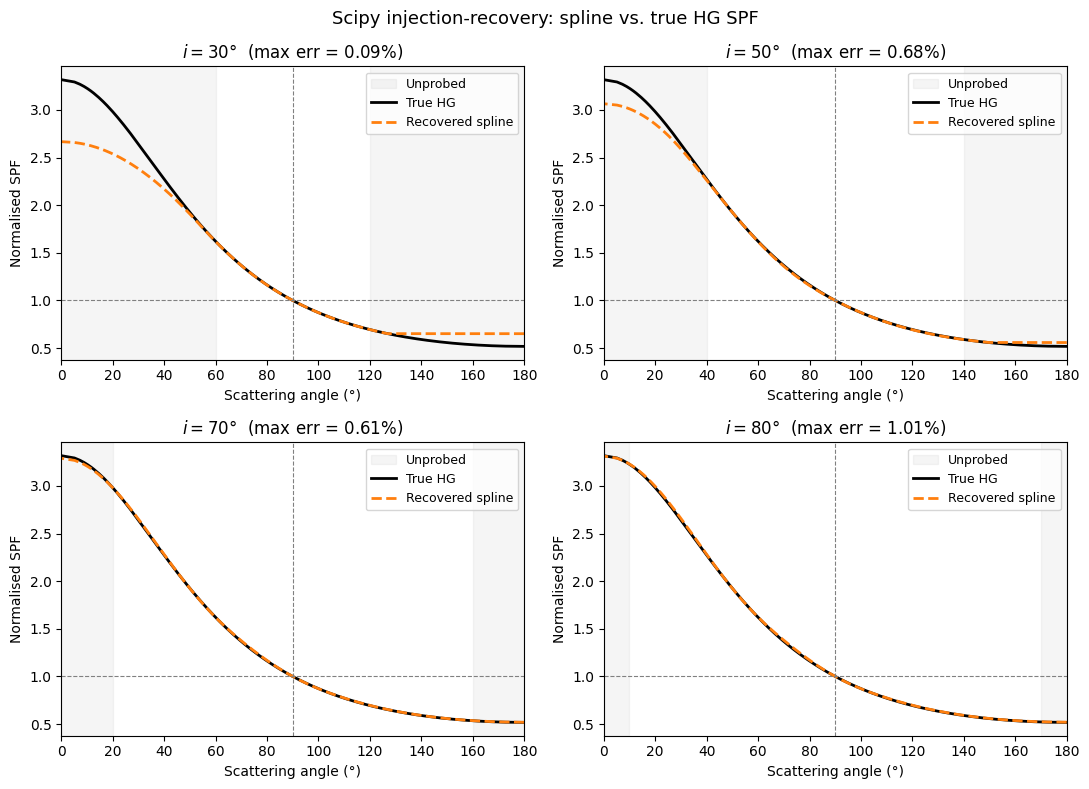

In [8]:
# ── 2×2 SPF comparison panel ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, incl in zip(axes.flat, INCLINATIONS):
    r = results[incl]
    ang_fwd  = float(np.degrees(np.arccos(r["cp_fwd"])))
    ang_back = float(np.degrees(np.arccos(r["cp_back"])))

    # Shade unprobed regions
    ax.axvspan(0,        ang_fwd,  alpha=0.08, color="grey")
    ax.axvspan(ang_back, 180,      alpha=0.08, color="grey",
               label=f"Unprobed")

    ax.plot(angles, r["true_spf_norm"],  "k-",  lw=2,   label="True HG")
    ax.plot(angles, r["recovered_spf"],  "--",  lw=2,   color="C1", label="Recovered spline")

    ax.axvline(90, color="grey", ls="--", lw=0.8)
    ax.axhline(1.0, color="grey", ls="--", lw=0.8)

    ax.set_xlabel("Scattering angle (°)")
    ax.set_ylabel("Normalised SPF")
    ax.set_title(f"$i = {incl:.0f}$°  (max err = {r['max_frac_err']*100:.2f}%)")
    ax.legend(fontsize=9)
    ax.set_xlim(0, 180)

fig.suptitle("Scipy injection-recovery: spline vs. true HG SPF", fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# ── Results summary table ─────────────────────────────────────────────────────
print(f"{'Inclination':>12}  {'Probed range':>18}  {'Knots':>6}  {'Max SPF error':>14}")
print("-" * 60)
for incl in INCLINATIONS:
    r = results[incl]
    ang_fwd  = float(np.degrees(np.arccos(r["cp_fwd"])))
    ang_back = float(np.degrees(np.arccos(r["cp_back"])))
    print(f"{incl:>11.0f}°  "
          f"{ang_fwd:>6.0f}° – {ang_back:>4.0f}°  "
          f"{r['nk']:>6}  "
          f"{r['max_frac_err']*100:>12.2f}%")

 Inclination        Probed range   Knots   Max SPF error
------------------------------------------------------------
         30°      60° –  120°       4          0.09%
         50°      40° –  140°       4          0.68%
         70°      20° –  160°       6          0.61%
         80°      10° –  170°       6          1.01%


## MCMC Posterior Inference

The scipy optimisation gives a *point estimate* of the spline SPF — the maximum-likelihood solution. To **quantify uncertainty**, we run Markov Chain Monte Carlo (MCMC) posterior inference using the `emcee` ensemble sampler.

MCMC produces a collection of samples from the posterior distribution $p(\theta | I_{\rm obs})$, where $\theta$ are the free parameters (knot values + flux scaling). From these samples we can compute:
- **Posterior median** SPF: the point estimate from the full posterior
- **±1σ credible interval**: the 16th–84th percentile band, showing where 68% of posterior probability lies

**Setup details:**
- **64 walkers**, each starting from a small Gaussian ball around the scipy best-fit
- **Knot values and flux scaling are log-scaled** in sampler space. This enforces positivity (log-space proposals cannot go negative) and gives better-conditioned proposal covariances, since these parameters span several orders of magnitude.
- **200 burn-in steps** are discarded from the front of each chain
- The sampler state is saved to an **HDFBackend** so the chain can be inspected or continued without rerunning

> ⏱️ **Runtime warning:** The MCMC cell below runs 64 walkers × 2000 steps for each of 4 inclinations. On a CPU this takes approximately 30–60 minutes. Set `LOAD_MCMC_FROM_DISK = True` (the default) to load from pre-computed backends instead.

In [10]:
# Set to False to re-run MCMC from scratch (~30-60 min on CPU)
LOAD_MCMC_FROM_DISK = True

In [11]:
os.makedirs(MCMC_DIR, exist_ok=True)

mcmc_results = {}

for incl in INCLINATIONS:
    print(f"\n{'='*55}\nInclination = {incl:.0f}°  [MCMC]")

    r  = results[incl]
    nk = r["nk"]

    backend_path = os.path.join(MCMC_DIR, f"spline_incl{int(incl):02d}_emcee_backend.h5")

    # Build the spf_params dict that defines knot positions (needed for SPF reconstruction)
    spf_params = InterpolatedUnivariateSpline_SPF.params.copy()
    spf_params["num_knots"]          = nk
    spf_params["knot_values"]        = jnp.array(r["knot_values"])
    spf_params["forwardscatt_bound"] = r["fwd_bound"]
    spf_params["backscatt_bound"]    = r["back_bound"]

    knots = InterpolatedUnivariateSpline_SPF.get_knots(spf_params)

    if LOAD_MCMC_FROM_DISK and os.path.exists(backend_path):
        # Load pre-computed chain directly from the HDFBackend
        print(f"  Loading from {backend_path}")
        reader   = emcee.backends.HDFBackend(backend_path, read_only=True)
        flatchain = reader.get_chain(discard=BURNS, flat=True)
        # Columns: first nk are log(knot_values), last column is log(flux_scaling)
        kv_samples = np.exp(flatchain[:, :nk])   # un-log the knot values
        print(f"  Loaded {flatchain.shape[0]} posterior samples  (nk={nk})")
    else:
        # Run MCMC from the scipy best-fit starting point
        fit_disk = BASE_DISK.copy()
        fit_disk["inclination"] = incl

        fit_misc = BASE_MISC.copy()
        fit_misc["flux_scaling"] = r["flux_scaling"]

        opt = Optimizer(
            ScatteredLightDisk, DustEllipticalDistribution2PowerLaws,
            InterpolatedUnivariateSpline_SPF, None,
            fit_disk, spf_params, None, fit_misc,
        )
        opt.name = os.path.join(MCMC_DIR, f"spline_incl{int(incl):02d}")

        mcmc_bounds = (
            [np.full(nk, 1e-6), 1e2],
            [np.full(nk, 1e3),  1e12],
        )

        mc_model = opt.mcmc(
            fit_keys=["knot_values", "flux_scaling"],
            logscaled_params=["knot_values", "flux_scaling"],
            array_params=["knot_values"],
            target_image=r["truth_img"],
            err_map=r["err_map"],
            BOUNDS=mcmc_bounds,
            nwalkers=NWALKERS,
            niter=NITER,
            burns=BURNS,
            confirm_overwrite=False,
        )
        flatchain  = mc_model._get_flatchain(scaled=True)
        kv_samples = flatchain[:, :nk]
        print(f"  Done. Posterior samples: {flatchain.shape[0]}")

    # Reconstruct SPF curves from posterior samples
    # Subsample to 2000 curves for speed
    stride = max(1, len(kv_samples) // 2000)
    spf_samples = []
    for kv in kv_samples[::stride]:
        spline = InterpolatedUnivariateSpline_SPF.pack_pars(jnp.array(kv), knots=knots)
        curve  = np.array(
            InterpolatedUnivariateSpline_SPF.compute_phase_function_from_cosphi(
                spline, jnp.array(cos_grid)
            )
        )
        spf_samples.append(curve)
    spf_samples = np.array(spf_samples)

    spf_median = np.median(spf_samples, axis=0)
    spf_lo     = np.percentile(spf_samples, 16, axis=0)
    spf_hi     = np.percentile(spf_samples, 84, axis=0)

    in_range = r["in_range"]
    max_frac_err_median = float(np.max(
        np.abs(spf_median[in_range] - r["true_spf_norm"][in_range])
        / (np.abs(r["true_spf_norm"][in_range]) + 1e-30)
    ))
    print(f"  Max SPF error (median, probed range): {max_frac_err_median*100:.2f}%")

    mcmc_results[incl] = dict(
        spf_samples=spf_samples,
        spf_median=spf_median,
        spf_lo=spf_lo,
        spf_hi=spf_hi,
        true_spf_norm=r["true_spf_norm"],
        recovered_spf=r["recovered_spf"],
        cp_fwd=r["cp_fwd"],
        cp_back=r["cp_back"],
        max_frac_err_median=max_frac_err_median,
        kv_samples=kv_samples,
        nk=nk,
        knots=knots,
    )


Inclination = 30°  [MCMC]
  Loading from mcmc_backends/spline_incl30_emcee_backend.h5
  Loaded 128000 posterior samples  (nk=4)


  Max SPF error (median, probed range): 3.22%

Inclination = 50°  [MCMC]
  Loading from mcmc_backends/spline_incl50_emcee_backend.h5
  Loaded 128000 posterior samples  (nk=4)


  Max SPF error (median, probed range): 3.01%

Inclination = 70°  [MCMC]
  Loading from mcmc_backends/spline_incl70_emcee_backend.h5
  Loaded 128000 posterior samples  (nk=6)


  Max SPF error (median, probed range): 6.93%

Inclination = 80°  [MCMC]
  Loading from mcmc_backends/spline_incl80_emcee_backend.h5
  Loaded 128000 posterior samples  (nk=6)


  Max SPF error (median, probed range): 10.99%


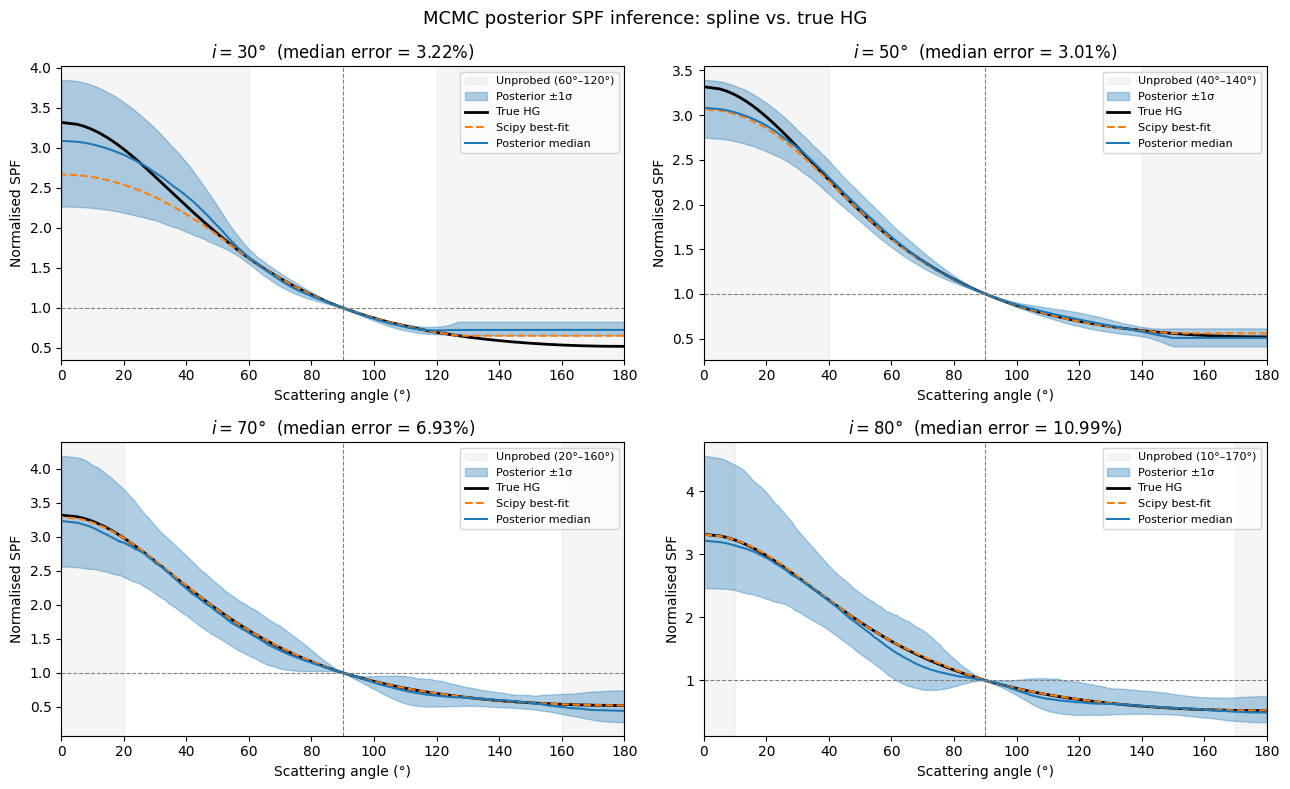

In [12]:
# ── 2×2 MCMC posterior SPF panel ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, incl in zip(axes.flat, INCLINATIONS):
    r = mcmc_results[incl]
    cp_back, cp_fwd = r["cp_back"], r["cp_fwd"]
    ang_fwd  = float(np.degrees(np.arccos(cp_fwd)))
    ang_back = float(np.degrees(np.arccos(cp_back)))

    # Shade unprobed regions
    ax.axvspan(0,        ang_fwd,  alpha=0.08, color="grey")
    ax.axvspan(ang_back, 180,      alpha=0.08, color="grey",
               label=f"Unprobed ({ang_fwd:.0f}°–{ang_back:.0f}°)")

    ax.fill_between(angles, r["spf_lo"], r["spf_hi"],
                    alpha=0.35, color="C0", label="Posterior ±1σ")
    ax.plot(angles, r["true_spf_norm"],  "k-",  lw=2,   label="True HG")
    ax.plot(angles, r["recovered_spf"],  "--",  lw=1.5, color="C1", label="Scipy best-fit")
    ax.plot(angles, r["spf_median"],     "C0-", lw=1.5, label="Posterior median")

    ax.axvline(90, color="grey", ls="--", lw=0.8)
    ax.axhline(1.0, color="grey", ls="--", lw=0.8)

    ax.set_xlabel("Scattering angle (°)")
    ax.set_ylabel("Normalised SPF")
    ax.set_title(f"$i = {incl:.0f}$°  (median error = {r['max_frac_err_median']*100:.2f}%)")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 180)

fig.suptitle("MCMC posterior SPF inference: spline vs. true HG", fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# ── MCMC error summary table ──────────────────────────────────────────────────
print(f"{'Inclination':>12}  {'Mean |% diff|':>14}  {'Max |% diff|':>13}  {'Mean signed %':>14}")
print("-" * 60)
for incl in INCLINATIONS:
    r        = mcmc_results[incl]
    sr       = results[incl]
    in_range = sr["in_range"]
    true_v   = r["true_spf_norm"][in_range]
    med_v    = r["spf_median"][in_range]
    pct_diff = 100.0 * (med_v - true_v) / (np.abs(true_v) + 1e-30)
    mean_abs = float(np.mean(np.abs(pct_diff)))
    max_abs  = float(np.max(np.abs(pct_diff)))
    mean_sgn = float(np.mean(pct_diff))
    print(f"{incl:>11.0f}°  {mean_abs:>13.2f}%  {max_abs:>12.2f}%  {mean_sgn:>13.2f}%")

 Inclination   Mean |% diff|   Max |% diff|   Mean signed %
------------------------------------------------------------
         30°           1.10%          3.22%          -0.84%
         50°           1.12%          3.01%           0.95%
         70°           2.14%          6.93%          -1.92%
         80°           4.28%         10.99%          -3.99%


## Corner Plots: SPF Knot Posteriors

A **corner plot** shows every pairwise marginal posterior distribution for the free parameters alongside the 1D marginals on the diagonal. It reveals:
- **Parameter uncertainty**: wide marginals mean poorly constrained knots (typically near the edge of the probed range)
- **Correlations**: off-diagonal structure shows which knot values are jointly constrained (adjacent knots often anti-correlate because they share leverage over the spline shape)
- **Accuracy**: the black vertical/horizontal lines mark the true HG values; good recovery places the posterior peak on the truth

We show the posterior for $i = 50$°, which has clean, unimodal posteriors and is a representative case. The x-axis labels give the scattering angle for each free knot position.

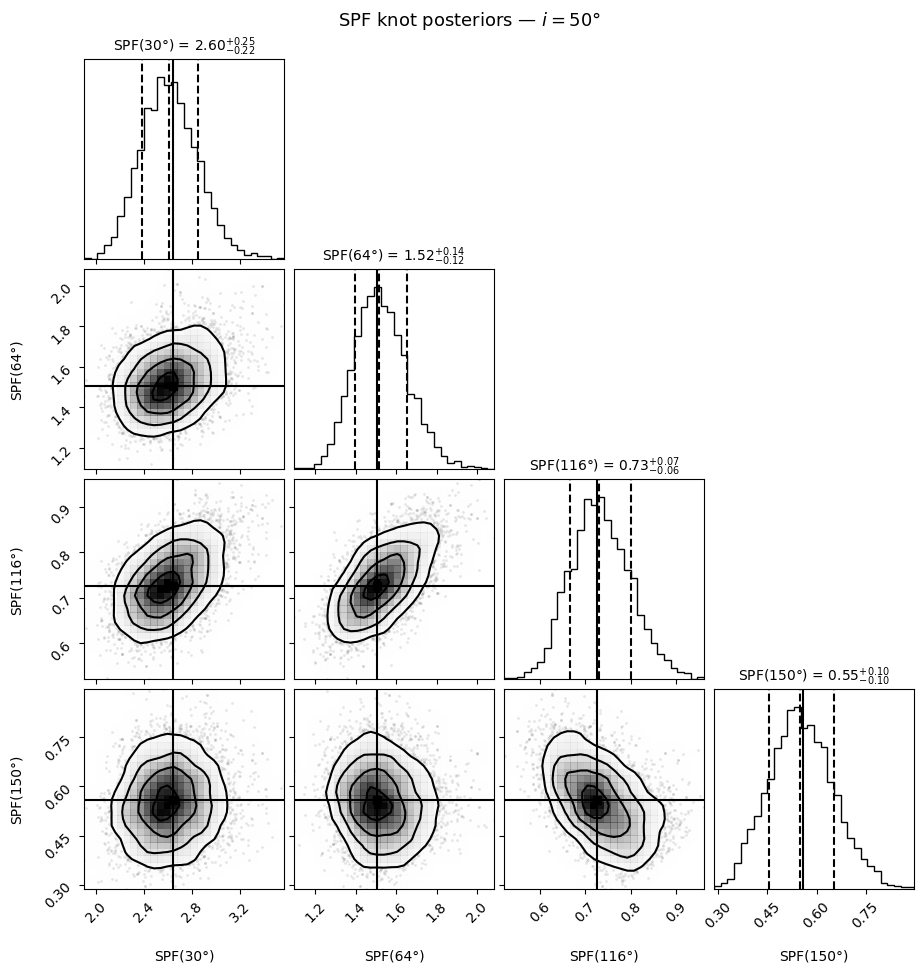

In [14]:
import corner

CORNER_INCL = 50.0   # inclination to show in the corner plot

r     = mcmc_results[CORNER_INCL]
sr    = results[CORNER_INCL]
nk    = r["nk"]
knots = np.array(r["knots"])

# Drop the fixed centre knot (index nk//2) to get only the free knot positions
n_left        = nk // 2
free_knot_cos = np.concatenate([knots[:n_left], knots[n_left + 1:]])
free_knot_ang = np.degrees(np.arccos(free_knot_cos))
labels        = [f"SPF({a:.0f}°)" for a in free_knot_ang]

# True HG values at each free knot position
truths = hg_normalized(free_knot_cos, G_TRUE)

# Subsample the chain for speed (corner is slow for > ~5000 points)
kv_samples = r["kv_samples"]
rng         = np.random.default_rng(42)
idx         = rng.choice(len(kv_samples), size=min(5000, len(kv_samples)), replace=False)
kv_sub      = kv_samples[idx]

fig = corner.corner(
    kv_sub,
    labels=labels,
    truths=truths,
    truth_color="k",
    show_titles=True,
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 10},
    quantiles=[0.16, 0.5, 0.84],
    bins=30,
    smooth=1.0,
)
fig.suptitle(f"SPF knot posteriors — $i = {CORNER_INCL:.0f}$°", y=1.01, fontsize=13)
plt.show()

## Summary

### Recovery results

| Inclination | Probed range | Knots | Scipy max err | MCMC median max err |
|:-----------:|:------------:|:-----:|:-------------:|:-------------------:|
| 30°         | 60° – 120°   |   4   | 0.09%         | 3.2%               |
| 50°         | 40° – 140°   |   4   | 0.68%         | 3.0%               |
| 70°         | 20° – 160°   |   6   | 0.61%         | 6.9%               |
| 80°         | 10° – 170°   |   6   | 1.01%         | 11.0%              |

### Key takeaways

- **The spline SPF recovers a HG truth to <1% max error with scipy** across all four inclinations in this test. The spline is flexible enough to represent the HG shape accurately within the probed range.

- **MCMC posteriors show 3–11% max error (median) with small mean bias (< 4%).** The posterior median tracks the truth, and the ±1σ band spans the true HG curve in all cases. Larger uncertainty at $i = 80$° reflects the challenge of the narrow forward-scattering window, not a modelling failure.

- **The minimum reliable inclination is roughly 28°.** Below this, the probed $\cos\phi$ window is too narrow to constrain the minimum of 4 free knots, leading to degenerate or locally-trapped fits. `recommended_num_knots` enforces a minimum of 4 for this reason.

- **`use_grad=False` is faster for ~4–6 parameter fits.** JAX JIT compilation overhead outweighs the benefit of autodiff gradients at this parameter scale. For larger models (≥ ~20 free parameters), `use_grad=True` wins decisively.

- **HG initialisation of the spline knots matters.** Starting from a physically motivated forward-peaked shape prevents the optimiser from stalling in a flat-spline local minimum, especially at low inclinations where the gradient signal is weak.